# Data harmonization

Notebook by Augustein de Boer, adapted by Alice Chavanne, adapted by Johanna Bayer. This workbook is part of this publication:

de Boer, A. A. A., Bayer, J. M. M., Fraza, C., Chavanne, A., Rehak Buckova, B., Tsilimparis, K., Serin, E., Bernas, A., Cirstian, R., Zabihi, M., Rutherford, S., Al Khaledi, A., Wolfers, T., Beckmann, C., & Marquand, A. F. (2026). Protocol update: The normative modelling paradigm for computational psychiatry. In bioRxiv (p. 2026.02.17.706268). bioRxiv. https://doi.org/10.64898/2026.02.17.706268

# Introduction

Data from different batches may have different characteristics, and in order to make sense of the entirety of the data, those characteristics have to be brought into agreement, which is what we call harmonization. When a model is fitted to data from different batches with the PCNtoolkit, a set of parameters is learned for each batch. These parameters describe an invertible mapping from feature space to deviation space. The deviation space is assumed to follow a standard normal distribution for each batch, so in order to harmonize data, we simply map all features from all batches to deviation space first, and then map all of them back using a single set of learned parameters. The choice for the set of parameters that is used for the inverse mapping is arbitrary, here we choose the batch effect that occurs first alphabetically. 

## 1. Setup and Imports

Load the core PCNtoolkit classes and plotting/data libraries used throughout this notebook.

In [ ]:
! pip install pcntoolkit

In [1]:
# Load the model
from pcntoolkit import NormativeModel
from pcntoolkit.util.plotter import plot_centiles_advanced
import pandas as pd
import logging
from pcntoolkit import NormData
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

logger = logging.getLogger("pymc")
logger.setLevel(logging.ERROR)


## 2. Load Pre-Fitted Reference Model

This model defines the reference distribution used later for harmonization across sites.

In [ ]:
# Let's assume we have a pre-fitted model that we want to hamonize our model to: Change to your file path
model = NormativeModel.load("/Users/johannabayer/Documents/Github/OHBM2026_Educational_course_harmonization/notebooks/block04/block4_utils/models/main_workflow_model_HBR")

## 3. Load and Inspect FCON1000 Data

Read the dataset, harmonize sex coding to labels, and do a quick sanity check of site coverage.

In [3]:
# Load data

try:
    df = pd.read_csv("../../data/fcon1000.csv")
except FileNotFoundError:
    # Load the data from the GH repo if the local file is not present
    df = pd.read_csv(
        "https://raw.githubusercontent.com/predictive-clinical-neuroscience/pu25_code/refs/heads/main/data/fcon1000.csv"
    )
df["sex"] = df.apply(lambda x: {0: "F", 1: "M"}[x["sex"]], axis=1)
print(df["site"].unique())
df.describe()

<ArrowStringArray>
[       'AnnArbor_a',        'AnnArbor_b',           'Atlanta',
         'Baltimore',            'Bangor',      'Beijing_Zang',
  'Berlin_Margulies', 'Cambridge_Buckner',         'Cleveland',
              'ICBM',       'Leiden_2180',       'Leiden_2200',
       'Milwaukee_b',           'Munchen',         'NewYork_a',
    'NewYork_a_ADHD',            'Newark',              'Oulu',
            'Oxford',          'PaloAlto',        'Pittsburgh',
        'Queensland',        'SaintLouis']
Length: 23, dtype: str


,age,lh_G_and_S_frontomargin,lh_G_and_S_occipital_inf,lh_G_and_S_paracentral,lh_G_and_S_subcentral,lh_G_and_S_transv_frontopol,lh_G_and_S_cingul-Ant,lh_G_and_S_cingul-Mid-Ant,lh_G_and_S_cingul-Mid-Post,lh_G_cingul-Post-dorsal,...,rh_S_pericallosal,rh_S_postcentral,rh_S_precentral-inf-part,rh_S_precentral-sup-part,rh_S_suborbital,rh_S_subparietal,rh_S_temporal_inf,rh_S_temporal_sup,rh_S_temporal_transverse,rh_MeanThickness
count,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,...,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000
mean,28.251224,2.372937,2.383840,2.310856,2.698957,2.610888,2.753899,2.697544,2.632217,2.959526,...,1.979635,2.104468,2.451929,2.417430,2.497463,2.401750,2.474282,2.495482,2.554019,2.485162
std,13.464724,0.192185,0.170751,0.190248,0.182866,0.225693,0.179482,0.179243,0.158939,0.195792,...,0.281369,0.161474,0.160934,0.182979,0.400458,0.162933,0.207039,0.139035,0.313909,0.097570
min,7.880000,1.653000,1.889000,1.383000,2.147000,1.910000,2.151000,2.158000,2.028000,2.240000,...,1.144000,1.635000,1.744000,1.503000,1.585000,1.897000,1.583000,1.943000,1.618000,2.056150
25%,21.000000,2.244250,2.267250,2.184250,2.574000,2.460000,2.629000,2.581000,2.529000,2.840250,...,1.773250,1.997000,2.354000,2.307000,2.208250,2.291250,2.365000,2.406500,2.330000,2.423033
50%,22.000000,2.361500,2.382000,2.313000,2.691500,2.608000,2.749500,2.703500,2.641000,2.956000,...,1.943500,2.100000,2.450000,2.433000,2.437000,2.400000,2.498500,2.499000,2.538500,2.487950
75%,29.000000,2.486000,2.498750,2.444000,2.821000,2.750750,2.865000,2.818750,2.739000,3.088500,...,2.155500,2.218750,2.554000,2.537750,2.730500,2.508000,2.607000,2.587000,2.768500,2.547210
max,85.000000,3.047000,3.010000,3.021000,3.438000,3.432000,3.542000,3.330000,3.143000,3.608000,...,3.119000,2.681000,3.042000,2.960000,4.066000,2.944000,3.111000,2.978000,3.581000,2.837260


## 4. Define Model Inputs and Build NormData

Specify covariates, batch effects, and response variables, then convert the dataframe into a NormData object with basic cleaning.

In [4]:
subject_id = "sub_id"
covariates = ["age"]
batch_effects = ["site", "sex"]
non_respvars = [subject_id] + covariates + batch_effects

# Only keep variable that are not covariates, batch effects, or subject id
response_variables = filter(lambda x: x not in non_respvars, df.columns)
# Only keep variables with variance
response_variables = filter(lambda x: df[x].var() > 0, response_variables)
# Only keep variables that are not categorical
response_variables = filter(lambda x: df[x].dtype != "object", response_variables)
# Only keep the first 5
response_variables = list(response_variables)[:5]


reference_norm_data = NormData.from_dataframe(
    name="fcon1000",
    dataframe=df,
    covariates=covariates,
    batch_effects=batch_effects,
    response_vars=response_variables,
    subject_ids=subject_id,
    remove_Nan=True,
    remove_outliers=True,
    z_threshold=10,  # The default here is 3, but we use 10 for demonstration purposes
)

Process: 75540 - 2026-06-11 12:09:45 - Removed 0 NANs
Process: 75540 - 2026-06-11 12:09:45 - Removed 0 outliers
Process: 75540 - 2026-06-11 12:09:45 - Dataset "fcon1000" created.
    - 1078 observations
    - 1078 unique subjects
    - 1 covariates
    - 5 response variables
    - 2 batch effects:
    	site (23)
	sex (2)
    


## 5. Configure the HBR Template

Define priors and sampler settings for a within-study normative model.

In [5]:
from pcntoolkit import make_prior, BsplineBasisFunction, NormalLikelihood, HBR, NormativeModel

mu = make_prior(
    # Mu is linear because we want to allow the mean to vary as a function of the covariates.
    linear=True,
    # The slope coefficients are assumed to be normally distributed, with a mean of 0 and a standard deviation of 2.
    slope=make_prior(dist_params=(0, 2)),
    # The intercept is random, because we expect the intercept to vary between sites and sexes.
    intercept=make_prior(
        random=True,
        # Mu is the mean of the intercept, which is normally distributed with a mean of 0 and a standard deviation of 1.
        mu=make_prior(dist_params=(0.0, 1.0)),
        # Sigma is the scale at which the intercepts vary. It is a positive parameter, so we have to map it to the positive domain.
        sigma=make_prior(
            dist_params=(3.0, 1.0),
            mapping="softplus",
            mapping_params=(0.0, 2.0),
        ),
    ),
    # We use a B-spline basis function to allow for non-linearity in the mean.
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    # Sigma is also linear, because we want to allow the standard deviation to vary as a function of the covariates: heteroskedasticity.
    linear=True,
    # The slope coefficients are assumed to be normally distributed, with a mean of 0 and a standard deviation of 2.
    slope=make_prior(dist_params=(0.0, 2.0)),
    # The intercept is not random, because we assume the intercept of the variance to be the same for all sites and sexes.
    intercept=make_prior(dist_params=(3.0, 2.0)),
    # We use a B-spline basis function to allow for non-linearity in the standard deviation.
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    # We use a softplus mapping to ensure that sigma is strictly positive.
    mapping="softplus",
    # We scale the softplus mapping by a factor of 3, to avoid spikes in the resulting density.
    # The parameters (a, b, c) provided to a mapping f are used as: f_abc(x) = f((x - a) / b) * b + c
    # This basically provides an affine transformation of the softplus function.
    # a -> horizontal shift
    # b -> scaling
    # c -> vertical shift
    # You can leave c out, and it will default to 0.
    mapping_params=(0.0, 2.0),
)

# Set the likelihood with the priors we just created.
likelihood = NormalLikelihood(mu, sigma)

template_hbr = HBR(
    name="template_hbr",
    # The likelihood we just created.
    likelihood=likelihood,
    ### Sampling parameters
    # The number of draws to sample from the posterior per chain.
    draws=1500,
    # The number of tuning steps to run.
    tune=500,
    # The number of cores to use for sampling.
    cores=4,
    # The number of MCMC chains to run.
    chains=4,
    # The sampler to use for the model.
    nuts_sampler="nutpie",
    # The initialisation method for the samples
    init="jitter+adapt_diag",
    # Whether to show a progress bar during the model fitting.
    progressbar=True,
)

In [6]:
model2 = NormativeModel(
    template_regression_model=template_hbr,  # The HBR model we just configured
    savemodel=True,  # Whether to save the model after fitting -  defaults to True
    evaluate_model=True,  # Whether to evaluate the model after fitting -  defaults to True
    saveresults=True,  # Whether to save the results (Z_scores, centiles, logp, evaluation metrics) -  defaults to True
    saveplots=True,  # Whether to save the plots (centile curves and qq-plots) -  defaults to True
    save_dir="../out/models/within_study",  # The directory to save the model
    inscaler="standardize",  # The scaler to use for the covariates, defaults to standardize
    outscaler="standardize",  # The scaler to use for the response variables, defaults to standardize
    name="within_study"# The path where the model will be saved
)


## 6. Fit Within-Study Model

Instantiate and fit a model directly on the FCON1000-derived NormData object.

In [7]:
model2.fit_predict(reference_norm_data, reference_norm_data)

Process: 75540 - 2026-06-11 12:09:56 - Fitting models on 5 response variables.
Process: 75540 - 2026-06-11 12:09:56 - Fitting model for lh_G_and_S_frontomargin.


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.22,63
,2000,0,0.18,31
,2000,0,0.20,63
,2000,0,0.19,127


Process: 75540 - 2026-06-11 12:10:31 - Fitting model for lh_G_and_S_occipital_inf.


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.21,31
,2000,1,0.20,31
,2000,0,0.17,63
,2000,0,0.19,63


Process: 75540 - 2026-06-11 12:10:54 - Fitting model for lh_G_and_S_paracentral.


...

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.19,31
,2000,0,0.17,31
,2000,0,0.17,15
,2000,0,0.19,47


Process: 75540 - 2026-06-11 12:11:46 - Fitting model for lh_G_and_S_transv_frontopol.


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.20,63
,2000,0,0.18,127
,2000,0,0.18,63
,2000,0,0.20,127


Process: 75540 - 2026-06-11 12:12:11 - Saving model to:
	../out/models/within_study.
Process: 75540 - 2026-06-11 12:12:12 - Making predictions on 5 response variables.
Process: 75540 - 2026-06-11 12:12:12 - Computing z-scores for 5 response variables.
Process: 75540 - 2026-06-11 12:12:12 - Computing z-scores for lh_G_and_S_frontomargin.
Process: 75540 - 2026-06-11 12:12:13 - Computing z-scores for lh_G_and_S_paracentral.
Process: 75540 - 2026-06-11 12:12:14 - Computing z-scores for lh_G_and_S_transv_frontopol.
Process: 75540 - 2026-06-11 12:12:15 - Computing z-scores for lh_G_and_S_subcentral.
Process: 75540 - 2026-06-11 12:12:16 - Computing z-scores for lh_G_and_S_occipital_inf.
Process: 75540 - 2026-06-11 12:12:17 - Computing centiles for 5 response variables.
Process: 75540 - 2026-06-11 12:12:17 - Computing centiles for lh_G_and_S_frontomargin.
Process: 75540 - 2026-06-11 12:12:20 - Computing centiles for lh_G_and_S_paracentral.
Process: 75540 - 2026-06-11 12:12:24 - Computing centi

<xarray.NormData> Size: 605kB
Dimensions:            (observations: 1078, response_vars: 5, covariates: 1,
                        batch_effect_dims: 2, statistic: 11, centile: 5)
Coordinates:
  * observations       (observations) int64 9kB 0 1 2 3 ... 1074 1075 1076 1077
  * response_vars      (response_vars) <U27 540B 'lh_G_and_S_frontomargin' .....
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'site' 'sex'
  * statistic          (statistic) <U8 352B 'EXPV' 'MACE' ... 'SMSE' 'ShapiroW'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
Data variables:
    subject_ids        (observations) object 9kB 'AnnArbor_a_sub04111' ... 'S...
    Y                  (observations, response_vars) float64 43kB 2.297 ... 2...
    X                  (observations, covariates) float64 9kB 25.63 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 147kB 'AnnArbor...
    Z                  (observations, response_vars) float64 43kB 0.09048 ......
    baseline_logp      (observations, response_vars) float64 43kB -0.9971 ......
    logp               (observations, response_vars) float64 43kB -0.7676 ......
    Yhat               (observations, response_vars) float64 43kB 2.283 ... 2.64
    statistics         (response_vars, statistic) float64 440B 0.2812 ... 0.993
    centiles           (centile, observations, response_vars) float64 216kB 2...
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000
    unique_batch_effects:           {np.str_('site'): ['AnnArbor_a', 'AnnArbo...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 7.88, 'max': 85.0}}
    batch_effect_covariate_ranges:  {np.str_('site'): {'AnnArbor_a': {np.str_...

## 7. Visualize Centiles Under a Chosen Reference Batch

Plot centiles after harmonizing to a chosen reference combination (for example, NewYork_a and F), while still showing selected comparison sites.

In [10]:
import os

# Pass explicit reference batch effects via the first entry in each batch-effect list.
# Here reference = site='NewYork_a', sex='F'.
reference_site = "NewYork_a"
reference_sex = "F"
sites_to_plot = ["Oulu", "Leiden_2180"]

available_sites = list(model2.batch_effects_maps["site"].keys())
available_sex = list(model2.batch_effects_maps["sex"].keys())

unknown_sites = [s for s in [reference_site] + sites_to_plot if s not in available_sites]
if unknown_sites:
    raise ValueError(f"Unknown site(s) for this fitted model: {unknown_sites}\nAvailable examples: {available_sites[:10]}")
if reference_sex not in available_sex:
    raise ValueError(f"Unknown sex '{reference_sex}'. Available: {available_sex}")

plot_batch_effects = {
    "site": [reference_site] + sites_to_plot,
    "sex": [reference_sex, "M" if reference_sex == "F" else "F"],
}

save_dir = "../out/plots"
os.makedirs(save_dir, exist_ok=True)

plot_centiles_advanced(
    model=model2,
    scatter_data=reference_norm_data,
    covariate="age",
    response_vars=[response_variables[0]],
    batch_effects=plot_batch_effects,
    harmonize_data=True,
    save_dir=save_dir,
)

Process: 75540 - 2026-06-11 12:16:02 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	site (1)
	sex (1)
    
Process: 75540 - 2026-06-11 12:16:02 - Computing centiles for 1 response variables.
Process: 75540 - 2026-06-11 12:16:02 - Computing centiles for lh_G_and_S_frontomargin.
Process: 75540 - 2026-06-11 12:16:04 - Harmonizing data on 1 response variables.
Process: 75540 - 2026-06-11 12:16:04 - Harmonizing data for lh_G_and_S_frontomargin.


## 8. Harmonize to External Reference Model

Apply harmonization using the pre-fitted main workflow model to map this dataset into the external reference space.

In [11]:
# Harmonize data
model.harmonize(reference_norm_data)

Process: 75540 - 2026-06-11 12:16:48 - Harmonizing data on 5 response variables.
Process: 75540 - 2026-06-11 12:16:48 - Harmonizing data for lh_G_and_S_frontomargin.
Process: 75540 - 2026-06-11 12:16:51 - Harmonizing data for lh_G_and_S_paracentral.
Process: 75540 - 2026-06-11 12:16:53 - Harmonizing data for lh_G_and_S_transv_frontopol.
Process: 75540 - 2026-06-11 12:16:54 - Harmonizing data for lh_G_and_S_subcentral.
Process: 75540 - 2026-06-11 12:16:56 - Harmonizing data for lh_G_and_S_occipital_inf.


<xarray.NormData> Size: 648kB
Dimensions:            (observations: 1078, response_vars: 5, covariates: 1,
                        batch_effect_dims: 2, statistic: 11, centile: 5)
Coordinates:
  * observations       (observations) int64 9kB 0 1 2 3 ... 1074 1075 1076 1077
  * response_vars      (response_vars) <U27 540B 'lh_G_and_S_frontomargin' .....
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'site' 'sex'
  * statistic          (statistic) <U8 352B 'EXPV' 'MACE' ... 'SMSE' 'ShapiroW'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
Data variables:
    subject_ids        (observations) object 9kB 'AnnArbor_a_sub04111' ... 'S...
    Y                  (observations, response_vars) float64 43kB 2.297 ... 2...
    X                  (observations, covariates) float64 9kB 25.63 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 147kB 'AnnArbor...
    Z                  (observations, response_vars) float64 43kB 0.09048 ......
    baseline_logp      (observations, response_vars) float64 43kB -0.9971 ......
    logp               (observations, response_vars) float64 43kB -0.7676 ......
    Yhat               (observations, response_vars) float64 43kB 2.283 ... 2.64
    statistics         (response_vars, statistic) float64 440B 0.2812 ... 0.993
    centiles           (centile, observations, response_vars) float64 216kB 2...
    Y_harmonized       (observations, response_vars) float64 43kB 2.297 ... 2...
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000
    unique_batch_effects:           {np.str_('site'): ['AnnArbor_a', 'AnnArbo...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 7.88, 'max': 85.0}}
    batch_effect_covariate_ranges:  {np.str_('site'): {'AnnArbor_a': {np.str_...

In [12]:
harmonized_y = reference_norm_data[("Y_harmonized")]
harmonized_y = harmonized_y.to_dataframe().reset_index().pivot(index="observations",columns="response_vars", values="Y_harmonized")
harmonized_y.columns = [f"harmonized_{c}" for c in harmonized_y.columns]
df_with_obs = df.merge(reference_norm_data[("subject_ids")].to_dataframe().reset_index(), left_on="sub_id", right_on="subject_ids")
df = pd.merge(left=df_with_obs, right=harmonized_y, on="observations")

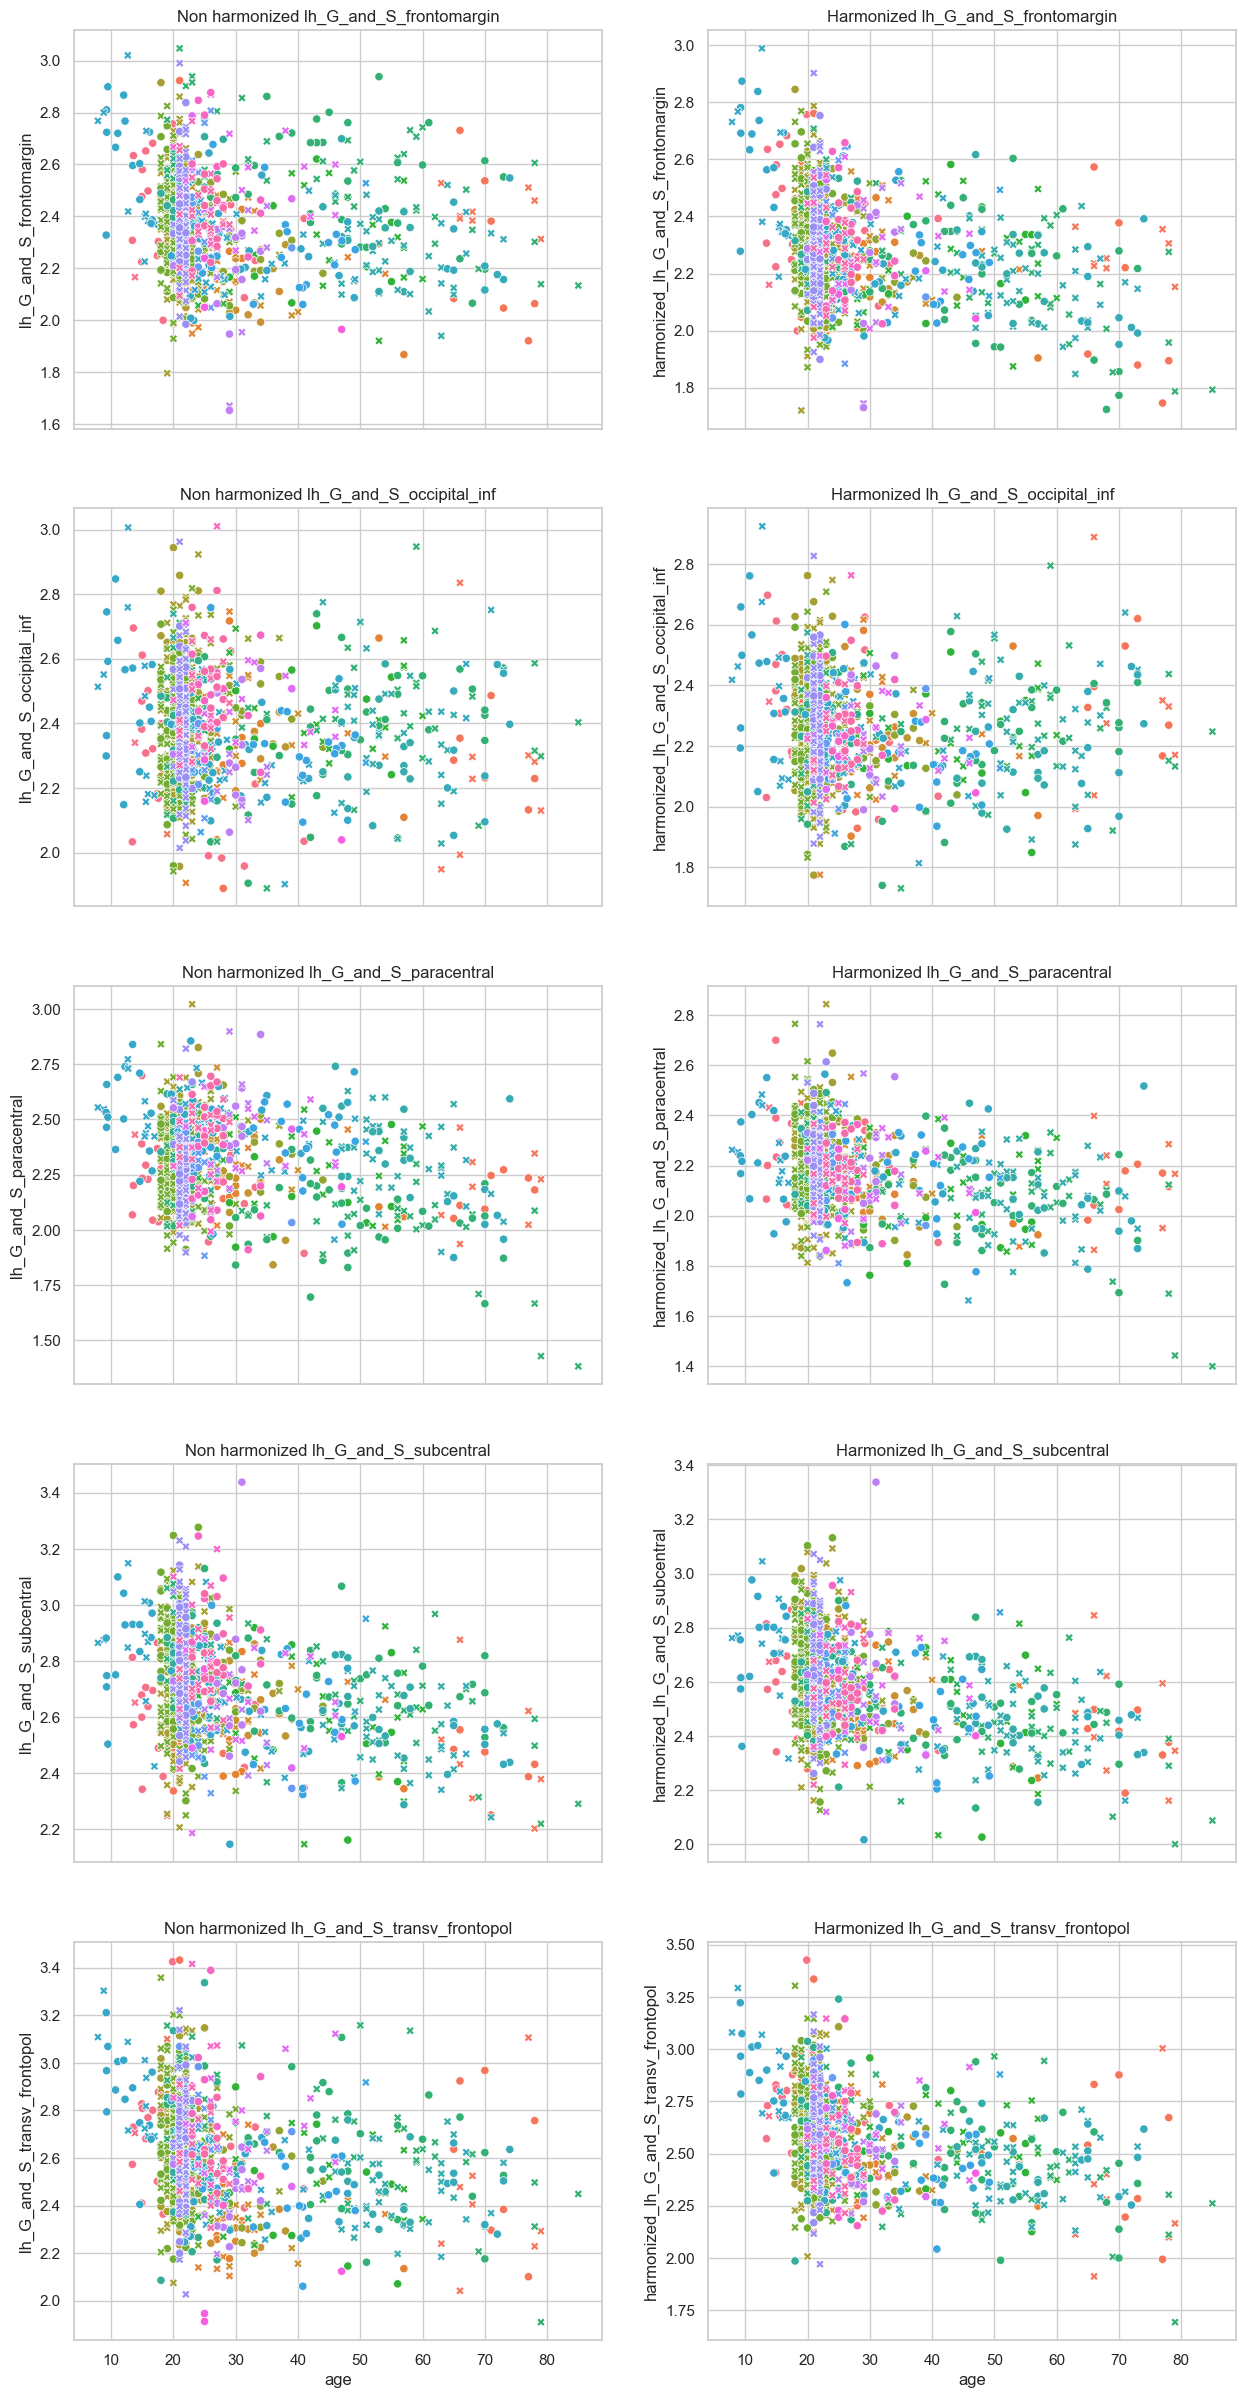

In [13]:
fig, ax = plt.subplots(len(response_variables),2, figsize=(15,30), sharex=True)

# First plot the data as it is 
for i, f in enumerate(response_variables):
    ax[i,0].set_title(f"Non harmonized {f}")
    ax[i,1].set_title(f"Harmonized {f}")
    sns.scatterplot(df, x="age", y=f, hue="site", style="sex", legend=False, ax=ax[i,0])
    sns.scatterplot(df, x="age", y=f"harmonized_{f}", hue="site", style="sex", legend=False, ax=ax[i,1])

plt.show()

## 9. Interpretation

After harmonization, site-driven spread is reduced and observations are brought onto a more comparable scale. This makes downstream analyses less sensitive to nuisance group effects.